# Lab 1: End-to-End Housing System with Regression and Clustering

<!--
This lab reviews weeks 2-5 through one realistic housing-data system. It follows the structure of the week 5 labs: read the explanation, run the code in order, answer the questions, and only then open the detailed solutions.

The matching Theory 1 file will explain the same ideas conceptually. This lab is the practical side.
-->

- [1. From a Business Question to Machine Learning Tasks](#1-from-a-business-question-to-machine-learning-tasks)
  - [1.1 Understand the business objective](#11-understand-the-business-objective)
  - [1.2 Separate the regression and clustering questions](#12-separate-the-regression-and-clustering-questions)
- [2. Load and Understand the Housing Dataset](#2-load-and-understand-the-housing-dataset)
  - [2.1 Import libraries](#21-import-libraries)
  - [2.2 Load the data](#22-load-the-data)
  - [2.3 Inspect rows, columns, and data types](#23-inspect-rows-columns-and-data-types)
  - [2.4 Identify features, target, and feature types](#24-identify-features-target-and-feature-types)
- [3. Initial EDA and Data Quality](#3-initial-eda-and-data-quality)
  - [3.1 Check missing values and duplicates](#31-check-missing-values-and-duplicates)
  - [3.2 Explore the target](#32-explore-the-target)
  - [3.3 Explore numerical relationships](#33-explore-numerical-relationships)
  - [3.4 Explore the categorical feature](#34-explore-the-categorical-feature)
  - [3.5 Investigate potential outliers](#35-investigate-potential-outliers)
- [4. Feature Engineering](#4-feature-engineering)
  - [4.1 Create ratio features](#41-create-ratio-features)
  - [4.2 Recheck the engineered features](#42-recheck-the-engineered-features)
- [5. Regression System: Predict Housing Value](#5-regression-system-predict-housing-value)
  - [5.1 Select features and target](#51-select-features-and-target)
  - [5.2 Split before learned preprocessing](#52-split-before-learned-preprocessing)
  - [5.3 Build a baseline](#53-build-a-baseline)
  - [5.4 Train simple linear regression](#54-train-simple-linear-regression)
  - [5.5 Prepare multiple-feature data](#55-prepare-multiple-feature-data)
  - [5.6 Train multiple linear regression](#56-train-multiple-linear-regression)
  - [5.7 Train polynomial regression](#57-train-polynomial-regression)
  - [5.8 Compare model performance and generalization](#58-compare-model-performance-and-generalization)
  - [5.9 Inspect predictions and residuals](#59-inspect-predictions-and-residuals)
  - [5.10 Interpret coefficients carefully](#510-interpret-coefficients-carefully)
- [6. Clustering System: Discover Similar District Profiles](#6-clustering-system-discover-similar-district-profiles)
  - [6.1 Change the question](#61-change-the-question)
  - [6.2 Select clustering features](#62-select-clustering-features)
  - [6.3 Standardize clustering features](#63-standardize-clustering-features)
  - [6.4 Compare candidate K values](#64-compare-candidate-k-values)
  - [6.5 Profile the selected K-Means clusters](#65-profile-the-selected-k-means-clusters)
  - [6.6 Visualize clusters geographically](#66-visualize-clusters-geographically)
  - [6.7 Compare with agglomerative clustering on a sample](#67-compare-with-agglomerative-clustering-on-a-sample)
  - [6.8 Read a dendrogram sample](#68-read-a-dendrogram-sample)
- [7. Connect the Lab to Real Project Practice](#7-connect-the-lab-to-real-project-practice)
- [8. Final Concept Review and Exam-Style Questions](#8-final-concept-review-and-exam-style-questions)

## Learning Objectives

By the end of this lab, you should be able to:

- translate a business objective into regression and clustering questions;
- inspect a real tabular dataset and identify features, target, and feature types;
- perform focused EDA before modeling;
- identify missing values, duplicates, unusual values, and potential outliers;
- create simple engineered features from domain reasoning;
- explain and avoid data leakage;
- create a train/test split for supervised learning;
- build and interpret a baseline regression model;
- train simple and multiple linear regression models;
- create polynomial features for a regression model;
- evaluate regression with MAE, RMSE, and R2;
- distinguish underfitting from overfitting using training and test error;
- interpret actual-vs-predicted and residual plots;
- distinguish regression from clustering;
- standardize features for distance-based clustering;
- use K-Means, inertia, silhouette scores, and cluster profiles;
- compare K-Means with agglomerative clustering at an introductory level;
- explain what the system can and cannot prove.

## 1. From a Business Question to Machine Learning Tasks

### 1.1 Understand the business objective

Imagine you have joined a housing analytics team. The team studies districts using census-style data. A district is a geographical area with measurements such as population, households, median income, and median house value.

The business team asks:

> Can we use district information to support housing-value analysis and district profiling?

This is not yet a machine-learning task. A real project starts by clarifying how the result will be used.

Possible uses include:

- estimating house values when direct estimates are unavailable;
- identifying districts with similar profiles;
- supporting human analysts who compare areas;
- summarizing patterns for decision makers.

In practice, the machine-learning model is not the whole business solution. It is one component in a larger decision process.

**Question 1 — Business objective versus model objective**

Why is "build a model" not enough as a project objective?

<details>
<summary>Solution</summary>

"Build a model" does not explain what the model is for. We need to know how the output will be used, what kind of mistake matters, what data will be available, and what evidence would make the model useful.

For example, predicting exact house value is a regression task. But if the business only needs categories such as low, medium, and high value, the task might become classification instead.

</details>

### 1.2 Separate the regression and clustering questions

This lab has two connected but different systems.

| System | Question | Learning type | Target used during fitting? |
|---|---|---|---|
| Regression | Can we predict `median_house_value`? | Supervised learning | Yes |
| Clustering | Which districts look similar? | Unsupervised learning | No |

The same dataset can support both questions, but the meaning of the model changes.

For regression, `median_house_value` is the target. The model learns from examples where the answer is known.

For clustering, we deliberately do **not** use `median_house_value` as a fitting feature. We use selected district characteristics to discover groups, then we may inspect house value afterward as part of interpretation.

**Question 2 — Regression or clustering?**

A housing analyst asks: "Given a district's income, population, location, and housing age, estimate its median house value." Is this regression or clustering?

<details>
<summary>Solution</summary>

This is regression because the goal is to predict a numerical target: `median_house_value`.

</details>

**Question 3 — Regression or clustering?**

A housing analyst asks: "Without using house values, group districts that have similar income, household, population, and location characteristics." Is this regression or clustering?

<details>
<summary>Solution</summary>

This is clustering because the goal is to discover groups from features without using a known target during fitting.

</details>

## 2. Load and Understand the Housing Dataset

### 2.1 Import libraries

Run this setup cell first.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

sns.set_theme(style="whitegrid")

**Code explanation**

- `pandas` stores the dataset as a table.
- `numpy` helps with numerical arrays.
- `matplotlib` and `seaborn` create plots for EDA and interpretation.
- `train_test_split` separates data used for learning from data used for evaluation.
- `SimpleImputer` fills missing values using a statistic learned from training data.
- `LinearRegression` fits a regression model.
- `PolynomialFeatures` creates squared and interaction terms for polynomial regression.
- MAE, RMSE, and R2 evaluate numerical predictions.
- `StandardScaler` standardizes features for distance-based clustering.
- `KMeans` and `AgglomerativeClustering` create clusters.
- `linkage` and `dendrogram` help visualize a hierarchy on a sample.

### 2.2 Load the data

Students will run this lab in Google Colab. There are two simple ways to make the CSV available.

**Option A: upload the CSV manually**

Upload `housing.csv` to the Colab session, then run:

In [2]:
# housing = pd.read_csv("/content/housing.csv")
# housing.head()

**Option B: download the CSV with `wget`**

Use this option when the course dataset URL is available:

In [3]:
!wget -O housing.csv https://raw.githubusercontent.com/AI-Learning-Repo/Data-Handling/refs/heads/week6/datasets/housing.csv
housing = pd.read_csv("housing.csv")
housing.head()


--2026-09-27 16:26:56--  https://raw.githubusercontent.com/AI-Learning-Repo/Data-Handling/refs/heads/week6/datasets/housing.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1423529 (1.4M) [text/plain]
Saving to: ‘housing.csv’

housing.csv         100%[===================>]   1.36M  --.-KB/s    in 0.06s   

2026-09-27 16:26:56 (22.7 MB/s) - ‘housing.csv’ saved [1423529/1423529]



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


For local testing before giving the lab to students, use the course folder path:

In [4]:
#housing = pd.read_csv("datasets/housing.csv")
#housing.head()

### 2.3 Inspect rows, columns, and data types

Before modeling, inspect the structure.

In [5]:
print("Rows and columns:", housing.shape)

Rows and columns: (20640, 10)


In [6]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [8]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**Code explanation**

- `shape` gives the number of rows and columns.
- `info()` shows column names, non-missing counts, and data types.
- `describe()` summarizes numerical columns.
- `head()` shows example rows.

These are not modeling steps. They help us understand what the dataset contains.

### 2.4 Identify features, target, and feature types

In this dataset:

- one row represents one district;
- `median_house_value` is the regression target;
- most columns are numerical;
- `ocean_proximity` is categorical.

In [9]:
target = "median_house_value"

numeric_columns = housing.select_dtypes(include="number").columns.tolist()
categorical_columns = housing.select_dtypes(exclude="number").columns.tolist()

print("Numerical columns:")
print(numeric_columns)
print()
print("Categorical columns:")
print(categorical_columns)

Numerical columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']

Categorical columns:
['ocean_proximity']


**Question 4 — Features and target**

Why should `median_house_value` not be included as an input feature when training a model to predict `median_house_value`?

<details>
<summary>Solution</summary>

That would give the model the answer as part of the input. The model would no longer be learning to predict house value from other district information.

This is a form of target leakage. It would make evaluation unrealistically good and useless for real prediction.

</details>

## 3. Initial EDA and Data Quality

### 3.1 Check missing values and duplicates

Real-world data is often incomplete or messy. Check missingness and duplicate rows.

In [10]:
missing_counts = housing.isna().sum().sort_values(ascending=False)
missing_counts

,0
total_bedrooms,207
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [11]:
duplicate_count = housing.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


**Code explanation**

- `isna()` checks each cell for missingness.
- `sum()` counts missing values per column.
- `duplicated()` identifies repeated rows.

**Question 5 — Missing values**

If `total_bedrooms` has missing values, why should we not simply ignore the issue?

<details>
<summary>Solution</summary>

Many machine-learning algorithms cannot work directly with missing values. Missingness can also tell us something about data quality.

We need to decide how to handle missing values. In this lab, we use median imputation for numerical features, but we fit the imputer only on the training data to avoid leakage.

</details>

### 3.2 Explore the target

The target is the value we want to predict.

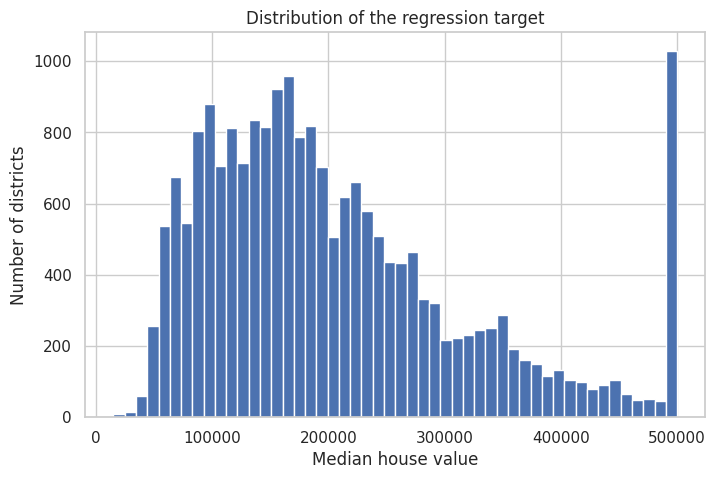

In [12]:
plt.figure(figsize=(8, 5))
housing["median_house_value"].hist(bins=50)
plt.xlabel("Median house value")
plt.ylabel("Number of districts")
plt.title("Distribution of the regression target")
plt.show()

In [13]:
housing["median_house_value"].describe()

,median_house_value
count,20640.000000
mean,206855.816909
std,115395.615874
min,14999.000000
25%,119600.000000
50%,179700.000000
75%,264725.000000
max,500001.000000


**Question 6 — Target distribution**

What should you notice about the maximum value of `median_house_value`? Why might that matter?

<details>
<summary>Solution</summary>

The maximum value is often visible as a strong upper edge in this dataset. This suggests that the target may be capped at an upper limit.

This matters because a model may have difficulty predicting values beyond that cap, and the cap can affect error patterns. We should mention this limitation when interpreting results.

</details>

### 3.3 Explore numerical relationships

Start with a relationship that is likely to matter: median income and house value.

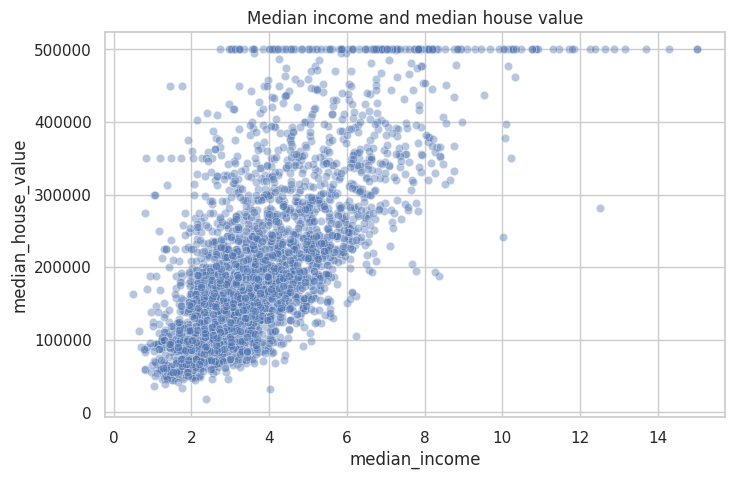

In [14]:
sample_for_plot = housing.sample(3000, random_state=42)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=sample_for_plot,
    x="median_income",
    y="median_house_value",
    alpha=0.4,
)
plt.title("Median income and median house value")
plt.show()

Now inspect correlations among numerical variables.

In [15]:
correlations = housing[numeric_columns].corr(numeric_only=True)
correlations[target].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


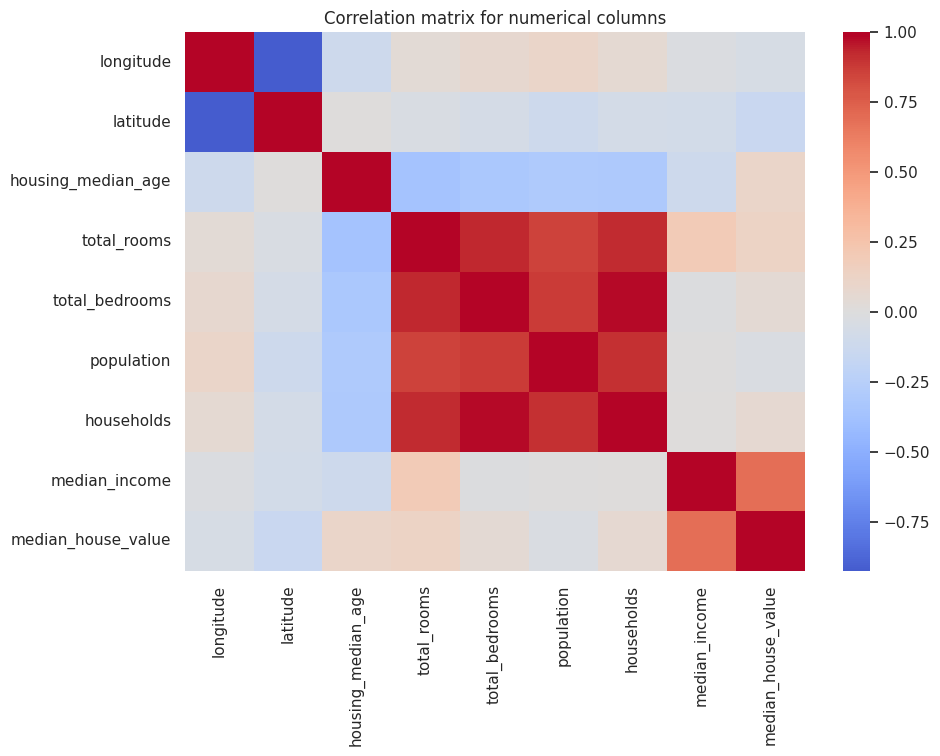

In [16]:
plt.figure(figsize=(10, 7))
sns.heatmap(correlations, cmap="coolwarm", center=0)
plt.title("Correlation matrix for numerical columns")
plt.show()

**Code explanation**

- A scatter plot helps us see the shape of a relationship.
- `corr()` calculates Pearson correlation between numerical columns.
- A heatmap helps compare many pairwise correlations.

**Question 7 — Correlation and causation**

If `median_income` is strongly correlated with `median_house_value`, can we conclude that changing income alone causes house value to change?

<details>
<summary>Solution</summary>

No. Correlation describes association, not causation.

Higher-income districts may also differ in location, housing supply, ocean proximity, age of buildings, population patterns, and many other factors. A predictive model can use correlations without proving causal relationships.

</details>

### 3.4 Explore the categorical feature

The column `ocean_proximity` is categorical.

In [17]:
housing["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


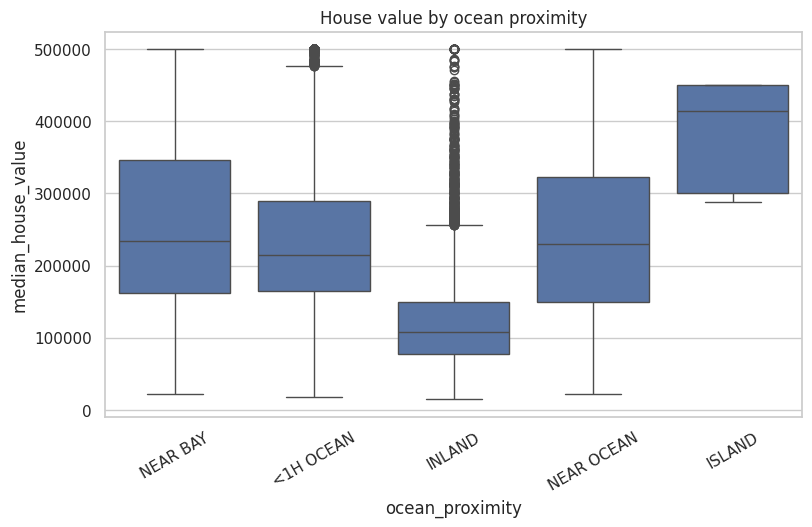

In [18]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=housing, x="ocean_proximity", y="median_house_value")
plt.xticks(rotation=30)
plt.title("House value by ocean proximity")
plt.show()

**Question 8 — Categorical variables**

Why should we not encode categories such as `NEAR BAY = 1`, `<1H OCEAN = 2`, and `INLAND = 3` as ordinary numbers for a linear model?

<details>
<summary>Solution</summary>

Those numbers would imply an artificial order and distance between categories. For example, the model might treat category 3 as greater than category 1 in a numerical sense.

For nominal categories, one-hot encoding is more appropriate because it creates separate indicator columns without inventing a false order.

</details>

### 3.5 Investigate potential outliers

Outliers are not automatically errors. They are observations that deserve investigation.

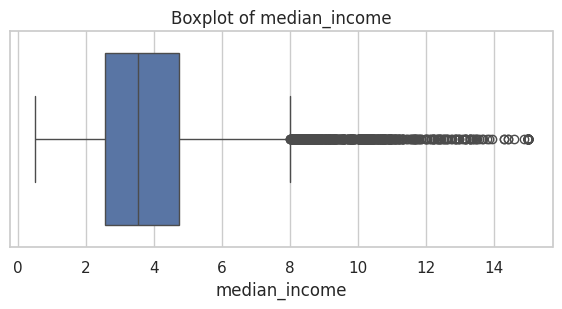

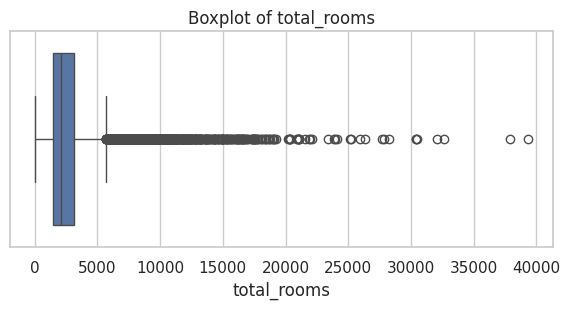

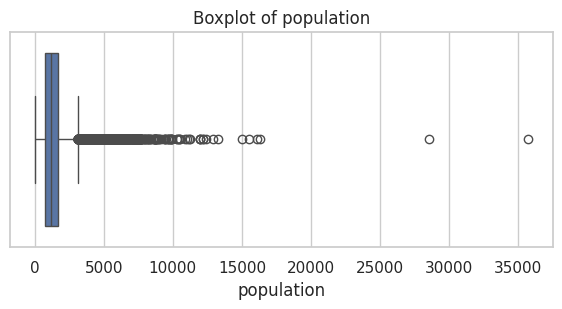

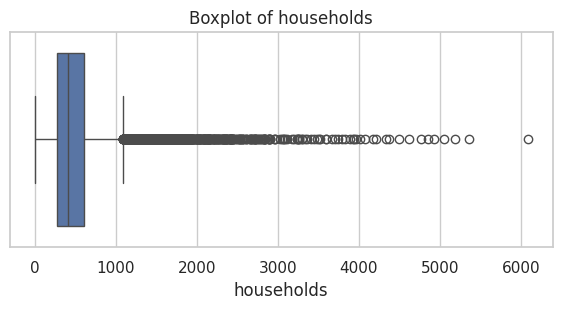

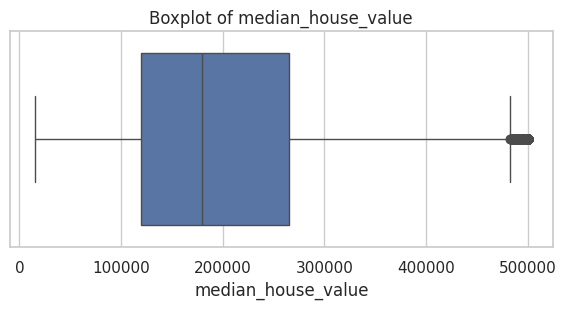

In [19]:
columns_to_boxplot = [
    "median_income",
    "total_rooms",
    "population",
    "households",
    "median_house_value",
]

for col in columns_to_boxplot:
    plt.figure(figsize=(7, 2.8))
    sns.boxplot(x=housing[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [20]:
housing[columns_to_boxplot].describe()

,median_income,total_rooms,population,households,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,2635.763081,1425.476744,499.539680,206855.816909
std,1.899822,2181.615252,1132.462122,382.329753,115395.615874
min,0.499900,2.000000,3.000000,1.000000,14999.000000
25%,2.563400,1447.750000,787.000000,280.000000,119600.000000
50%,3.534800,2127.000000,1166.000000,409.000000,179700.000000
75%,4.743250,3148.000000,1725.000000,605.000000,264725.000000
max,15.000100,39320.000000,35682.000000,6082.000000,500001.000000


**Question 9 — Outliers**

Should we automatically delete districts with very high `total_rooms` or `population`?

<details>
<summary>Solution</summary>

No. A district with many rooms or a large population may be unusual but valid.

The correct action depends on domain knowledge and the goal of the analysis. We should investigate unusual values before deciding to keep, transform, cap, or remove them.

</details>

## 4. Feature Engineering

### 4.1 Create ratio features

Raw totals can be hard to compare across districts. A district with many rooms may simply have many households.

Create ratios that describe districts more meaningfully.

In [21]:
housing_fe = housing.copy()

housing_fe["rooms_per_household"] = (
    housing_fe["total_rooms"] / housing_fe["households"]
)
housing_fe["bedrooms_per_room"] = (
    housing_fe["total_bedrooms"] / housing_fe["total_rooms"]
)
housing_fe["population_per_household"] = (
    housing_fe["population"] / housing_fe["households"]
)

housing_fe[
    ["rooms_per_household", "bedrooms_per_room", "population_per_household"]
].head()

,rooms_per_household,bedrooms_per_room,population_per_household
0,6.984127,0.146591,2.555556
1,6.238137,0.155797,2.109842
2,8.288136,0.129516,2.802260
3,5.817352,0.184458,2.547945
4,6.281853,0.172096,2.181467


**Code explanation**

- `rooms_per_household` describes average rooms per household.
- `bedrooms_per_room` describes the share of rooms that are bedrooms.
- `population_per_household` describes average people per household.

These are examples of feature engineering: creating useful variables from existing ones.

### 4.2 Recheck the engineered features

After creating features, inspect them.

In [22]:
engineered_features = [
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household",
]

housing_fe[engineered_features].describe()

,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20433.000000,20640.000000
mean,5.429000,0.213039,3.070655
std,2.474173,0.057983,10.386050
min,0.846154,0.100000,0.692308
25%,4.440716,0.175427,2.429741
50%,5.229129,0.203162,2.818116
75%,6.052381,0.239821,3.282261
max,141.909091,1.000000,1243.333333


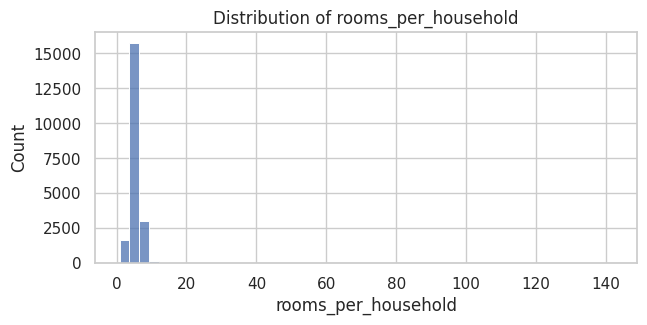

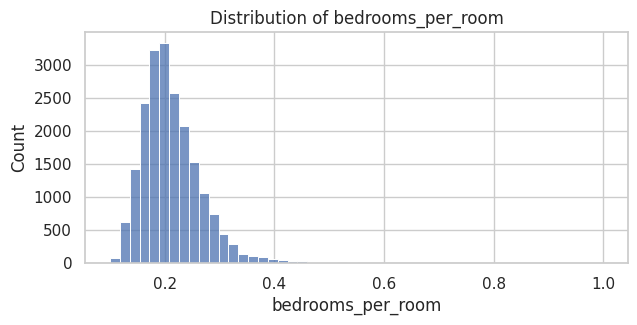

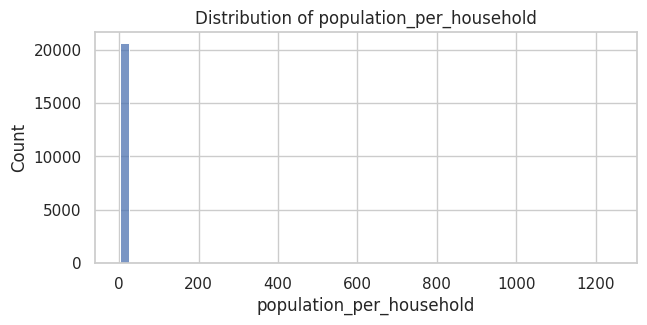

In [23]:
for col in engineered_features:
    plt.figure(figsize=(7, 3))
    sns.histplot(housing_fe[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.show()

**Question 10 — Feature engineering**

Why might `rooms_per_household` be more useful than `total_rooms`?

<details>
<summary>Solution</summary>

`total_rooms` is strongly affected by district size. A larger district may naturally have more rooms.

`rooms_per_household` adjusts for the number of households, so it better describes a district characteristic rather than only its size.

</details>

## 5. Regression System: Predict Housing Value

### 5.1 Select features and target

For the regression task, define `X` and `y`.

In [24]:
target = "median_house_value"

numeric_features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household",
]

categorical_features = ["ocean_proximity"]

X = housing_fe[numeric_features + categorical_features]
y = housing_fe[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 12)
y shape: (20640,)


**Code explanation**

- `X` contains the input features.
- `y` contains the target we want to predict.
- `median_house_value` is not included in `X`.

### 5.2 Split before learned preprocessing

Split the data before fitting imputers or models.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 16512
Test rows: 4128


**Question 11 — Leakage**

Why should we split before calculating the median used to fill missing values?

<details>
<summary>Solution</summary>

If we calculate the median using the full dataset, the test set influences preprocessing. The test set is supposed to represent unseen data.

Fitting preprocessing on the full dataset causes data leakage and can make evaluation look better than it really is.

</details>

### 5.3 Build a baseline

A baseline is a simple reference model.

Here the baseline predicts the median house value from the training data for every test example.

In [26]:
baseline_value = y_train.median()
baseline_predictions = np.full(shape=len(y_test), fill_value=baseline_value)

def regression_scores(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

results = []
results.append(
    regression_scores("Training median baseline", y_test, baseline_predictions)
)

pd.DataFrame(results)

,Model,MAE,RMSE,R2
0,Training median baseline,90457.292878,121659.531341,-0.067698


**Code explanation**

- `y_train.median()` uses only the training target values.
- `np.full()` creates one repeated prediction for every test row.
- The helper function calculates MAE, RMSE, and R2.

**Question 12 — Why use a baseline?**

Why is it not enough to say that a model has an RMSE of 80,000?

<details>
<summary>Solution</summary>

A metric needs context. An RMSE of 80,000 may be good or poor depending on how difficult the task is and how simple alternatives perform.

A baseline gives us a simple reference. A useful model should improve meaningfully over the baseline.

</details>

### 5.4 Train simple linear regression

Start with one feature: `median_income`.

In [27]:
simple_model = LinearRegression()
simple_model.fit(X_train[["median_income"]], y_train)

simple_predictions = simple_model.predict(X_test[["median_income"]])

results.append(
    regression_scores("Simple linear regression", y_test, simple_predictions)
)

pd.DataFrame(results)

,Model,MAE,RMSE,R2
0,Training median baseline,90457.292878,121659.531341,-0.067698
1,Simple linear regression,63599.031056,85046.431520,0.478243


In [28]:
print("Intercept:", simple_model.intercept_)
print("Coefficient for median_income:", simple_model.coef_[0])

Intercept: 46369.636813326535
Coefficient for median_income: 41345.40832927538


**Code explanation**

- `LinearRegression()` creates the model object.
- `fit()` learns the intercept and coefficient from training data.
- `predict()` generates predictions for test features.

**Question 13 — Coefficient interpretation**

What does the coefficient for `median_income` mean in this simple model?

<details>
<summary>Solution</summary>

The coefficient describes how much the model's predicted house value changes when `median_income` increases by one unit, according to this fitted straight-line relationship.

It is an association inside the model, not proof of causation.

</details>

### 5.5 Prepare multiple-feature data

Now use several numerical features and the categorical feature.

First, impute missing numerical values. Fit the imputer on training data only.

In [29]:
num_imputer = SimpleImputer(strategy="median")

X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[numeric_features]),
    columns=numeric_features,
    index=X_train.index,
)

X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[numeric_features]),
    columns=numeric_features,
    index=X_test.index,
)

print("Missing values after training imputation:")
print(X_train_num.isna().sum().sum())
print("Missing values after test imputation:")
print(X_test_num.isna().sum().sum())

Missing values after training imputation:
0
Missing values after test imputation:
0


**Code explanation**

- `fit_transform()` learns medians from the training data and applies them to training data.
- `transform()` applies the same learned medians to test data.
- We do not fit a new imputer on the test set.

Next, one-hot encode the categorical feature.

In [30]:
X_train_cat = pd.get_dummies(X_train[categorical_features], drop_first=True)
X_test_cat = pd.get_dummies(X_test[categorical_features], drop_first=True)

X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

display(X_train_cat.head())

,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
14196,False,False,False,True
8267,False,False,False,True
17445,False,False,True,False
14265,False,False,False,False
2271,True,False,False,False


**Code explanation**

- `pd.get_dummies()` converts categories into indicator columns.
- `drop_first=True` removes one reference category.
- `reindex()` ensures the test encoded columns match the training encoded columns.

Combine numerical and categorical data.

In [31]:
X_train_ready = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_ready = pd.concat([X_test_num, X_test_cat], axis=1)

print("Prepared training shape:", X_train_ready.shape)
print("Prepared test shape:", X_test_ready.shape)

Prepared training shape: (16512, 15)
Prepared test shape: (4128, 15)


**Question 14 — One-hot encoding**

Why must the prepared training and test feature tables have the same columns?

<details>
<summary>Solution</summary>

The model learns one coefficient for each training feature column. During prediction, the test data must contain the same feature columns in the same meaning.

If a test column is missing or a new column appears unexpectedly, the model input no longer matches what the model learned.

</details>

### 5.6 Train multiple linear regression

Fit a regression model using the prepared feature tables.

In [32]:
multiple_model = LinearRegression()
multiple_model.fit(X_train_ready, y_train)

multiple_predictions = multiple_model.predict(X_test_ready)

results.append(
    regression_scores("Multiple linear regression", y_test, multiple_predictions)
)

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2
0,Training median baseline,90457.292878,121659.531341,-0.067698
1,Simple linear regression,63599.031056,85046.431520,0.478243
2,Multiple linear regression,49842.491247,68794.154658,0.658603


### 5.7 Train polynomial regression

Linear regression fits a straight-line relationship in the features it receives.

Sometimes a relationship is curved. Polynomial regression handles this by creating extra features such as squared terms and interaction terms, then fitting a linear regression model on the expanded feature table.

To keep the example understandable, use only a small set of numerical features.

In [33]:
poly_base_features = [
    "median_income",
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household",
]

X_train_poly_base = X_train_num[poly_base_features]
X_test_poly_base = X_test_num[poly_base_features]

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_poly_base)
X_test_poly = poly.transform(X_test_poly_base)

print("Original feature count:", X_train_poly_base.shape[1])
print("Polynomial feature count:", X_train_poly.shape[1])

Original feature count: 4
Polynomial feature count: 14


In [34]:
poly_feature_names = poly.get_feature_names_out(poly_base_features)
poly_feature_names

array(['median_income', 'rooms_per_household', 'bedrooms_per_room',
       'population_per_household', 'median_income^2',
       'median_income rooms_per_household',
       'median_income bedrooms_per_room',
       'median_income population_per_household', 'rooms_per_household^2',
       'rooms_per_household bedrooms_per_room',
       'rooms_per_household population_per_household',
       'bedrooms_per_room^2',
       'bedrooms_per_room population_per_household',
       'population_per_household^2'], dtype=object)

In [35]:
polynomial_model = LinearRegression()
polynomial_model.fit(X_train_poly, y_train)

polynomial_predictions = polynomial_model.predict(X_test_poly)

results.append(
    regression_scores("Polynomial regression degree 2", y_test, polynomial_predictions)
)

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2
0,Training median baseline,90457.292878,121659.531341,-0.067698
1,Simple linear regression,63599.031056,85046.431520,0.478243
2,Multiple linear regression,49842.491247,68794.154658,0.658603
3,Polynomial regression degree 2,58037.204506,79274.377138,0.546662


**Code explanation**

- `PolynomialFeatures(degree=2)` creates original features, squared features, and pairwise interaction features.
- `fit_transform()` is used on the training data.
- `transform()` is used on the test data so the same transformation is applied.
- The model is still `LinearRegression`, but it receives an expanded feature table.

**Question 15 — Polynomial regression**

Why can polynomial regression model curved relationships even though it uses `LinearRegression()`?

<details>
<summary>Solution</summary>

`LinearRegression()` is linear in the coefficients it learns.

Polynomial regression first creates transformed features such as:

```text
median_income^2
median_income × rooms_per_household
```

After those features exist, a linear model can combine them with coefficients. The relationship can be nonlinear in the original input features even though the fitted model is linear in its coefficients.

</details>

### 5.8 Compare model performance and generalization

In [36]:
results_df.sort_values("RMSE")

,Model,MAE,RMSE,R2
2,Multiple linear regression,49842.491247,68794.154658,0.658603
3,Polynomial regression degree 2,58037.204506,79274.377138,0.546662
1,Simple linear regression,63599.031056,85046.431520,0.478243
0,Training median baseline,90457.292878,121659.531341,-0.067698


Also compare training and test RMSE. This helps us discuss underfitting and overfitting.

In [37]:
generalization_rows = []

model_predictions = [
    (
        "Simple linear regression",
        y_train,
        simple_model.predict(X_train[["median_income"]]),
        y_test,
        simple_predictions,
    ),
    (
        "Multiple linear regression",
        y_train,
        multiple_model.predict(X_train_ready),
        y_test,
        multiple_predictions,
    ),
    (
        "Polynomial regression degree 2",
        y_train,
        polynomial_model.predict(X_train_poly),
        y_test,
        polynomial_predictions,
    ),
]

for model_name, y_train_true, y_train_pred, y_test_true, y_test_pred in model_predictions:
    train_rmse = mean_squared_error(y_train_true, y_train_pred) ** 0.5
    test_rmse = mean_squared_error(y_test_true, y_test_pred) ** 0.5
    generalization_rows.append({
        "Model": model_name,
        "Training RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Gap": test_rmse - train_rmse,
    })

generalization_df = pd.DataFrame(generalization_rows)
generalization_df.sort_values("Test RMSE")

,Model,Training RMSE,Test RMSE,Gap
1,Multiple linear regression,67675.132188,68794.154658,1119.022471
2,Polynomial regression degree 2,76174.566256,79274.377138,3099.810883
0,Simple linear regression,83409.098994,85046.431520,1637.332526


**Code explanation**

- Training RMSE measures error on data used to fit the model.
- Test RMSE measures error on unseen data.
- A model with high training error and high test error may be underfitting.
- A model with very low training error but much higher test error may be overfitting.
- The best practical model is usually chosen using test performance, not training performance alone.

**Question 16 — Model comparison**

Which model performs best on the test set? Which metric supports your answer?

<details>
<summary>Solution</summary>

Use your output. In the local test run, the multiple-feature models performed better than the simple model and the baseline because they had lower MAE and RMSE and higher R2.

The important point is to compare models on the same test set using the same metrics.

</details>

**Question 17 — Underfitting and overfitting**

Suppose a model has high training RMSE and high test RMSE. Is that more likely underfitting or overfitting?

<details>
<summary>Solution</summary>

That pattern is more likely underfitting.

The model is not performing well even on the data it was trained on, so it may be too simple, missing important features, or unable to represent the relationship well.

</details>

**Question 18 — Training error versus test error**

Why should we not automatically choose the model with the lowest training RMSE?

<details>
<summary>Solution</summary>

A very flexible model can memorize patterns or noise in the training data. This can produce a low training RMSE but poor performance on new data.

The test set is more useful for estimating how the model may perform on unseen observations.

</details>

**Question 19 — MAE and RMSE**

Why is RMSE often larger than MAE?

<details>
<summary>Solution</summary>

RMSE squares errors before averaging and then takes the square root. Squaring gives larger errors more influence.

MAE averages absolute errors more directly. If a model makes some very large mistakes, RMSE will increase more strongly than MAE.

</details>

**Question 20 — R2**

Does `R2 = 0.65` mean that 65 percent of individual predictions are correct?

<details>
<summary>Solution</summary>

No. Regression predictions are numerical, not simply correct or incorrect.

R2 compares the model against a baseline that predicts the mean target value. It summarizes how much variation is explained relative to that baseline.

</details>

### 5.9 Inspect predictions and residuals

Metrics summarize performance, but plots help reveal patterns.

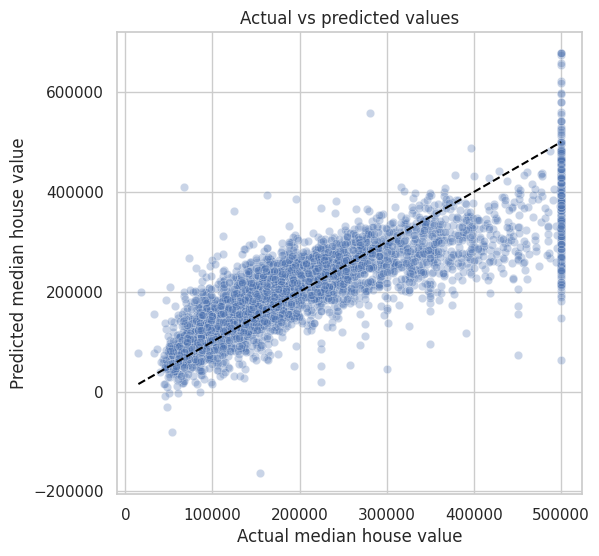

In [38]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=multiple_predictions, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--",
    color="black",
)
plt.xlabel("Actual median house value")
plt.ylabel("Predicted median house value")
plt.title("Actual vs predicted values")
plt.show()

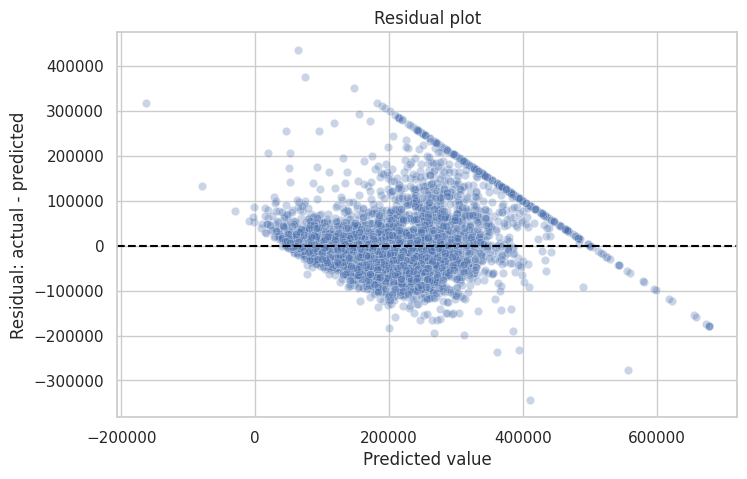

In [39]:
residuals = y_test - multiple_predictions

plt.figure(figsize=(8, 5))
sns.scatterplot(x=multiple_predictions, y=residuals, alpha=0.3)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted value")
plt.ylabel("Residual: actual - predicted")
plt.title("Residual plot")
plt.show()

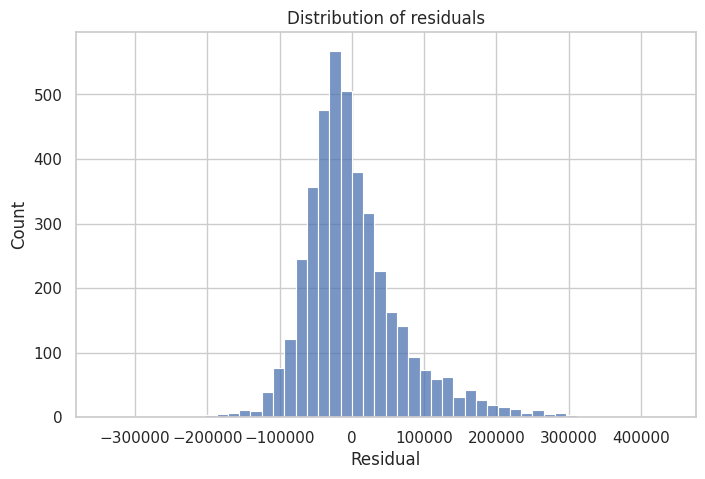

In [40]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=50)
plt.xlabel("Residual")
plt.title("Distribution of residuals")
plt.show()

**Code explanation**

- The actual-vs-predicted plot compares true values with model predictions.
- The diagonal line shows perfect prediction.
- Residuals are errors: `actual - predicted`.
- A residual plot helps us see whether errors show systematic patterns.

**Question 21 — Residual interpretation**

What does a positive residual mean?

<details>
<summary>Solution</summary>

A positive residual means:

```text
actual value - predicted value > 0
```

So the actual value is higher than the model predicted. The model underpredicted that district.

</details>

### 5.10 Interpret coefficients carefully

Inspect the coefficients from the multiple regression model.

In [41]:
coef_table = pd.DataFrame({
    "feature": X_train_ready.columns,
    "coefficient": multiple_model.coef_,
}).sort_values("coefficient", key=abs, ascending=False)

coef_table

,feature,coefficient
9,bedrooms_per_room,273873.684024
12,ocean_proximity_ISLAND,149679.658851
7,median_income,40646.146323
11,ocean_proximity_INLAND,-35878.358003
0,longitude,-26641.329718
1,latitude,-25272.283923
14,ocean_proximity_NEAR OCEAN,5187.291332
13,ocean_proximity_NEAR BAY,-3177.175731
8,rooms_per_household,2779.156153
2,housing_median_age,1055.824904


**Question 22 — Coefficients in multiple regression**

Why should coefficient interpretation be more careful in a multiple-feature model than in a simple one-feature model?

<details>
<summary>Solution</summary>

In multiple regression, a coefficient describes the model's expected prediction change for one feature while the other included features are held constant.

Features can be correlated with each other. Coefficients can also depend on units. Therefore, coefficients should be interpreted carefully and not treated as simple causal effects.

</details>

## 6. Clustering System: Discover Similar District Profiles

### 6.1 Change the question

Regression asked:

> Can we predict the known numerical target `median_house_value`?

Clustering asks:

> Which districts look similar based on selected characteristics?

For clustering, we do not supply `median_house_value` as a target. We also do not use it as a clustering feature. After fitting clusters, we can inspect house values to help describe the groups.

**Question 20 — Why remove the target?**

Why should `median_house_value` not be included in the clustering features if our goal is to discover district profiles based on other characteristics?

<details>
<summary>Solution</summary>

If `median_house_value` is included, the clusters may be strongly driven by the value we previously treated as the prediction target.

Leaving it out lets us ask a different question: which districts are similar according to income, household, population, and location characteristics? We can inspect house value afterward to describe the groups.

</details>

### 6.2 Select clustering features

Choose features that describe district profiles.

In [42]:
cluster_features = [
    "median_income",
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household",
    "latitude",
    "longitude",
]

cluster_df = housing_fe[
    cluster_features + ["median_house_value", "ocean_proximity"]
].dropna().copy()

print("Rows available for clustering:", len(cluster_df))
display(cluster_df[cluster_features].describe())

Rows available for clustering: 20433


,median_income,rooms_per_household,bedrooms_per_room,population_per_household,latitude,longitude
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,3.871162,5.431344,0.213039,3.071533,35.633221,-119.570689
std,1.899291,2.482946,0.057983,10.438269,2.136348,2.003578
min,0.499900,0.846154,0.100000,0.692308,32.540000,-124.350000
25%,2.563700,4.441441,0.175427,2.429032,33.930000,-121.800000
50%,3.536500,5.230769,0.203162,2.817582,34.260000,-118.490000
75%,4.744000,6.052381,0.239821,3.281513,37.720000,-118.010000
max,15.000100,141.909091,1.000000,1243.333333,41.950000,-114.310000


**Code explanation**

- `cluster_features` defines the coordinates used for similarity.
- `median_house_value` is kept only for later interpretation.
- `dropna()` removes rows missing selected clustering features for this introductory exercise.

### 6.3 Standardize clustering features

K-Means uses distances, so feature scale matters.

In [43]:
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(cluster_df[cluster_features])

scaled_check = pd.DataFrame(X_cluster_scaled, columns=cluster_features)
display(scaled_check.mean().round(6))
display(scaled_check.std(ddof=0).round(6))

,0
median_income,-0.0
rooms_per_household,-0.0
bedrooms_per_room,0.0
population_per_household,-0.0
latitude,0.0
longitude,-0.0


,0
median_income,1.0
rooms_per_household,1.0
bedrooms_per_room,1.0
population_per_household,1.0
latitude,1.0
longitude,1.0


**Question 21 — Scaling**

Why is scaling important for K-Means in this clustering task?

<details>
<summary>Solution</summary>

K-Means uses distances. If one feature has much larger numerical values than another, it can dominate the distance calculation.

Standardization puts features on comparable scales, so differences in income, ratios, latitude, and longitude can contribute more fairly under the chosen representation.

Scaling does not guarantee meaningful clusters; it is still a modeling choice.

</details>

### 6.4 Compare candidate K values

Fit K-Means for several values of K.

In [44]:
cluster_rows = []
labels_by_k = {}

for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_cluster_scaled)
    labels_by_k[k] = labels

    silhouette = silhouette_score(
        X_cluster_scaled,
        labels,
        sample_size=min(4000, len(cluster_df)),
        random_state=42,
    )

    cluster_rows.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette,
    })

cluster_scores = pd.DataFrame(cluster_rows)
cluster_scores

,K,Inertia,Silhouette
0,2,87403.563308,0.407337
1,3,72455.515200,0.379840
2,4,55747.325797,0.377999
3,5,48222.502842,0.368285
4,6,42999.377597,0.344685


The silhouette calculation uses a reproducible sample so the lab remains responsive in Colab.

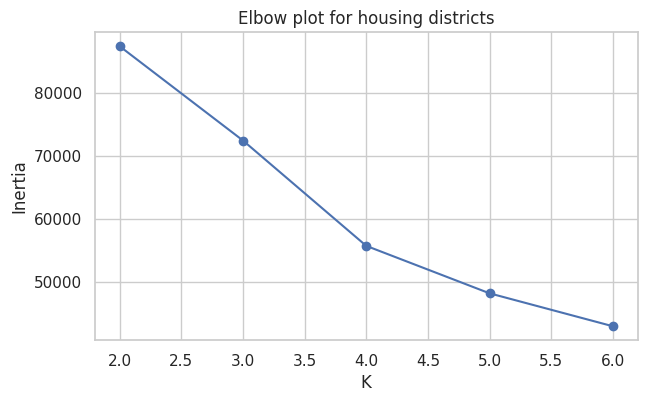

In [45]:
plt.figure(figsize=(7, 4))
plt.plot(cluster_scores["K"], cluster_scores["Inertia"], marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow plot for housing districts")
plt.show()

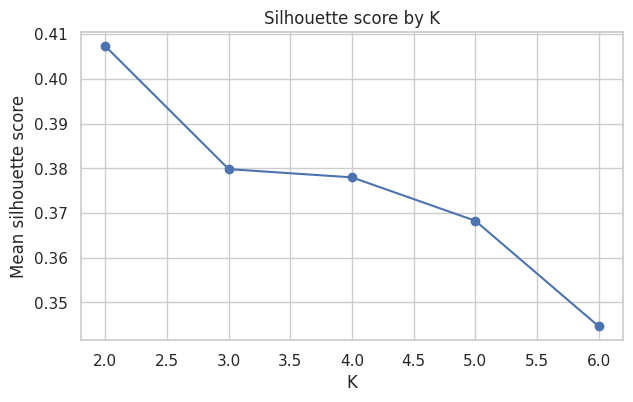

In [46]:
plt.figure(figsize=(7, 4))
plt.plot(cluster_scores["K"], cluster_scores["Silhouette"], marker="o")
plt.xlabel("K")
plt.ylabel("Mean silhouette score")
plt.title("Silhouette score by K")
plt.show()

**Code explanation**

- Inertia measures total squared distance to assigned centroids.
- Lower inertia alone does not prove a better clustering because adding clusters usually reduces inertia.
- Silhouette compares how close observations are to their own cluster versus other clusters.
- A higher silhouette is useful evidence, not absolute proof of meaningful groups.

**Question 22 — Choosing K**

Which K would you investigate further? Use both inertia and silhouette evidence.

<details>
<summary>Solution</summary>

Use your actual output. A defensible answer should mention both:

- the elbow plot: where inertia improvement begins to slow;
- silhouette: which K gives stronger separation under the selected representation.

If they disagree, that is not a failure. It means we need to inspect profiles, plots, group sizes, and the purpose of the clustering.

</details>

### 6.5 Profile the selected K-Means clusters

For this lab, choose the K with the highest silhouette score as a starting point for interpretation.

In [47]:
chosen_k = int(
    cluster_scores.sort_values("Silhouette", ascending=False).iloc[0]["K"]
)

print("Chosen K for profiling:", chosen_k)

cluster_df["kmeans_cluster"] = labels_by_k[chosen_k]

Chosen K for profiling: 2


Build cluster profiles in original units.

In [48]:
cluster_profile = (
    cluster_df
    .groupby("kmeans_cluster")
    .agg(
        districts=("kmeans_cluster", "size"),
        median_income=("median_income", "mean"),
        rooms_per_household=("rooms_per_household", "mean"),
        bedrooms_per_room=("bedrooms_per_room", "mean"),
        population_per_household=("population_per_household", "mean"),
        median_house_value=("median_house_value", "mean"),
    )
    .reset_index()
)

cluster_profile

,kmeans_cluster,districts,median_income,rooms_per_household,bedrooms_per_room,population_per_household,median_house_value
0,0,11801,3.912243,5.228359,0.219552,3.057025,213960.428099
1,1,8632,3.814998,5.708849,0.204135,3.091367,197163.292632


In [49]:
pd.crosstab(
    cluster_df["kmeans_cluster"],
    cluster_df["ocean_proximity"],
    normalize="index",
).round(3)

ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
kmeans_cluster,,,,,
0,0.630,0.218,0.0,0.000,0.151
1,0.185,0.455,0.0,0.263,0.097


**Question 23 — Cluster profiles**

What can a cluster profile support? What can it not prove?

<details>
<summary>Solution</summary>

A profile can support descriptions such as:

- this cluster has higher average median income;
- this cluster has larger average households;
- this cluster contains more inland districts;
- this cluster has higher or lower average house value after clustering.

It cannot prove causes. It also cannot prove that the clusters are natural real-world categories. The groups depend on selected features, scaling, algorithm, and K.

</details>

### 6.6 Visualize clusters geographically

Plot a sample of district clusters by longitude and latitude.

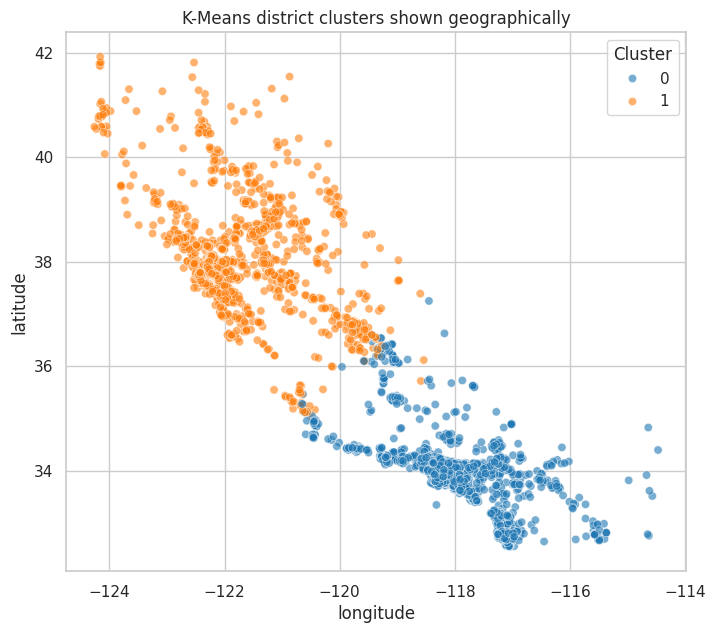

In [50]:
plot_sample = cluster_df.sample(
    min(5000, len(cluster_df)),
    random_state=42,
)

plt.figure(figsize=(8, 7))
sns.scatterplot(
    data=plot_sample,
    x="longitude",
    y="latitude",
    hue="kmeans_cluster",
    palette="tab10",
    alpha=0.6,
)
plt.title("K-Means district clusters shown geographically")
plt.legend(title="Cluster")
plt.show()

**Question 24 — Map interpretation**

If clusters appear geographically separated, does that prove geography caused the clusters?

<details>
<summary>Solution</summary>

No. Latitude and longitude were included as clustering features, so geography directly influenced the distance calculation.

The plot can help us interpret the groups, but it does not prove a causal relationship.

</details>

### 6.7 Compare with agglomerative clustering on a sample

Agglomerative clustering can be expensive on large datasets, so use a reproducible sample.

In [51]:
agg_sample = cluster_df.sample(2000, random_state=42).copy()
agg_sample_scaled = cluster_scaler.transform(agg_sample[cluster_features])

agg_model = AgglomerativeClustering(
    n_clusters=chosen_k,
    linkage="ward",
)
agg_sample["agg_cluster"] = agg_model.fit_predict(agg_sample_scaled)

print("Agglomerative cluster counts:")
print(agg_sample["agg_cluster"].value_counts().sort_index())

Agglomerative cluster counts:
agg_cluster
0    1167
1     833
Name: count, dtype: int64


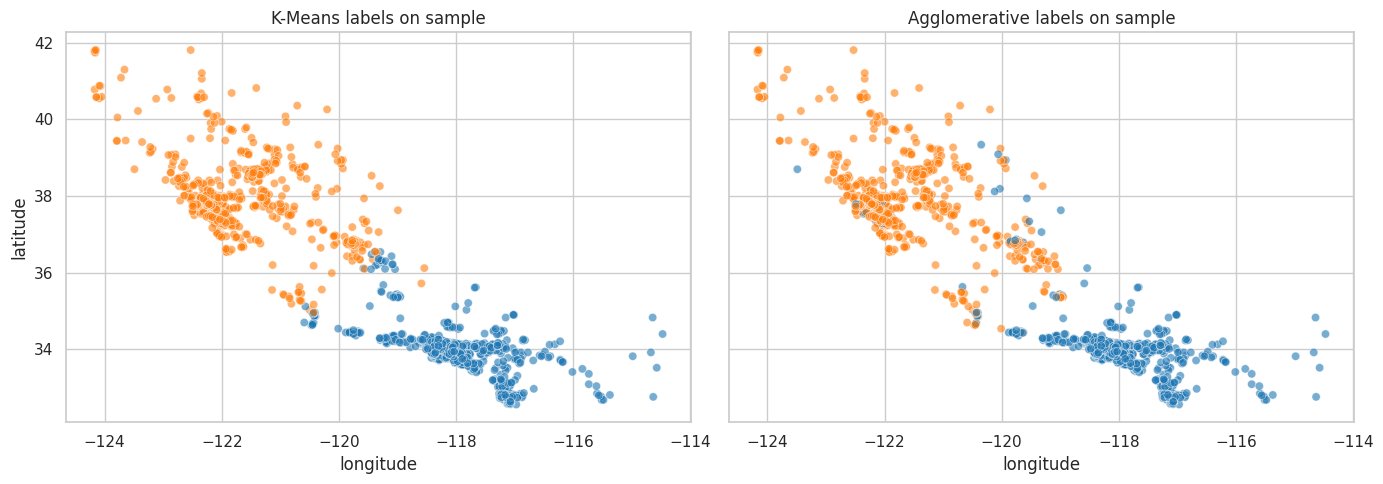

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

sns.scatterplot(
    data=agg_sample,
    x="longitude",
    y="latitude",
    hue="kmeans_cluster",
    palette="tab10",
    alpha=0.6,
    ax=axes[0],
    legend=False,
)
axes[0].set_title("K-Means labels on sample")

sns.scatterplot(
    data=agg_sample,
    x="longitude",
    y="latitude",
    hue="agg_cluster",
    palette="tab10",
    alpha=0.6,
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Agglomerative labels on sample")

plt.tight_layout()
plt.show()

**Code explanation**

- K-Means repeatedly assigns observations to centroids and updates centroids.
- Agglomerative clustering starts with individual observations and repeatedly merges groups.
- The two methods can produce different groups even with the same features and number of clusters.

**Question 25 — Different algorithms**

If K-Means and agglomerative clustering produce different memberships, does that automatically mean one is wrong?

<details>
<summary>Solution</summary>

No. They use different procedures.

K-Means uses centroids and reassignment. Agglomerative clustering builds a hierarchy through merges. Different algorithms can answer the same broad clustering question differently.

We compare results using evidence: profiles, plots, sizes, silhouette, interpretability, and the purpose of the analysis.

</details>

### 6.8 Read a dendrogram sample

A full dendrogram for thousands of districts would be unreadable. Use a small sample to practice reading the hierarchy.

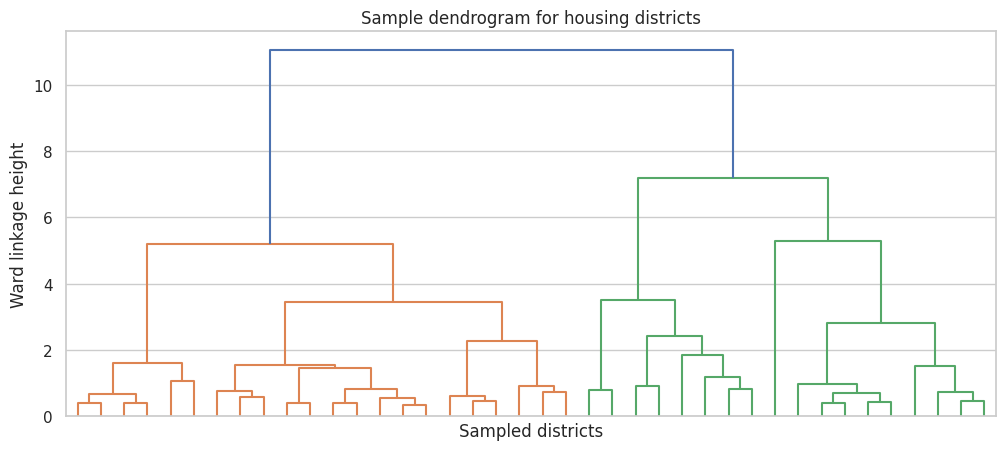

In [53]:
dendro_sample = cluster_df.sample(40, random_state=7).copy()
dendro_scaled = cluster_scaler.transform(dendro_sample[cluster_features])

linked = linkage(dendro_scaled, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(linked, no_labels=True)
plt.title("Sample dendrogram for housing districts")
plt.xlabel("Sampled districts")
plt.ylabel("Ward linkage height")
plt.show()

**Question 26 — Dendrogram**

What does a high merge in a dendrogram suggest?

<details>
<summary>Solution</summary>

A high merge suggests that the groups being joined were relatively far apart according to the linkage criterion.

For Ward linkage, the height relates to the increase in within-cluster variation caused by a merge. Large jumps can suggest possible cut levels, but they do not prove a uniquely correct number of clusters.

</details>

## 7. Connect the Lab to Real Project Practice

This lab used a simplified but realistic workflow:

```text
Business question
    ↓
Data loading and inspection
    ↓
EDA and data quality checks
    ↓
Feature engineering
    ↓
Regression model for prediction
    ↓
Evaluation on held-out test data
    ↓
Clustering model for district profiles
    ↓
Interpretation, limitations, and communication
```

In real work, engineers and analysts also ask:

- Where did the data come from?
- Is the data current and reliable?
- What does each row represent?
- Which columns are available before prediction time?
- Are there missing values or unusual values?
- Which model errors would be most costly?
- How should results be explained to non-technical users?
- What limitations must be stated clearly?

This lab does not implement advanced engineering infrastructure. The goal is to understand the reasoning and core workflow using concepts covered in class.

**Question 27 — Real-world assumptions**

Why should we check assumptions before building a model?

<details>
<summary>Solution</summary>

If the assumptions are wrong, the model may solve the wrong problem.

For example, if the business needs categories but we build a numerical regression model, the output may not match the real need. If a feature would not be available for future districts, using it in training would make the model unrealistic.

</details>

## 8. Final Concept Review and Exam-Style Questions

Answer these before opening the solutions.

### Q1. What is the difference between a feature and a target?

<details>
<summary>Solution</summary>

A feature is an input variable used by the model. The target is the value we want to predict in supervised learning.

In this lab, features included columns such as `median_income`, `latitude`, and `ocean_proximity`. The regression target was `median_house_value`.

</details>

### Q2. Why did we use a train/test split for regression?

<details>
<summary>Solution</summary>

The model learns from the training data. The test data is held back to evaluate performance on data the model did not use during fitting.

This helps estimate generalization to new observations.

</details>

### Q3. What is data leakage?

<details>
<summary>Solution</summary>

Data leakage happens when information that should not be available during training influences the model or preprocessing.

Example from this lab: calculating imputation medians using the full dataset before splitting would let the test set influence training preparation.

</details>

### Q4. Why did we use median imputation?

<details>
<summary>Solution</summary>

Median imputation fills missing numerical values with the median of available values. It is often more robust than the mean when a feature is skewed or contains extreme values.

In this lab, the median was learned from training data and then applied to both training and test data.

</details>

### Q5. Why did we use one-hot encoding?

<details>
<summary>Solution</summary>

Machine-learning models usually require numerical inputs. `ocean_proximity` contains categories, so one-hot encoding turns it into indicator columns.

This avoids imposing a false numerical order on categories.

</details>

### Q6. What is a baseline model?

<details>
<summary>Solution</summary>

A baseline is a simple reference prediction. It helps us decide whether a real model adds value.

In this lab, the baseline predicted the training median house value for every test district.

</details>

### Q7. What do MAE, RMSE, and R2 measure?

<details>
<summary>Solution</summary>

MAE is the average absolute prediction error.

RMSE is the square root of the average squared prediction error. It gives larger errors more influence.

R2 compares the model against a mean-prediction baseline and summarizes explained variation relative to that baseline.

</details>

### Q8. What is the difference between regression and clustering?

<details>
<summary>Solution</summary>

Regression is supervised learning. It predicts a numerical target from features.

Clustering is unsupervised learning. It groups observations based on feature similarity without using a target during fitting.

</details>

### Q9. Why did we scale features before K-Means?

<details>
<summary>Solution</summary>

K-Means uses distance. Features with larger numerical scales can dominate distance calculations.

Standardization makes features more comparable under Euclidean distance.

</details>

### Q10. Why is the lowest inertia not enough to choose K?

<details>
<summary>Solution</summary>

Inertia usually decreases when K increases because more centroids can fit the data more closely.

If every observation had its own centroid, inertia could become zero, but that would not be a useful summary. We need additional evidence such as elbow shape, silhouette, profiles, and interpretability.

</details>

### Q11. What does a silhouette score describe?

<details>
<summary>Solution</summary>

Silhouette compares how close an observation is to points in its own cluster versus points in the nearest competing cluster.

Values near 1 suggest better separation. Values near 0 suggest overlap. Negative values suggest the observation may be closer to another cluster under the selected distance.

</details>

### Q12. Why are cluster numbers not meaningful by themselves?

<details>
<summary>Solution</summary>

Cluster numbers are arbitrary identifiers. Cluster 0 is not automatically "low" or "best."

Meaning comes from profiling the observations assigned to each cluster.

</details>

### Q13. Does clustering prove natural groups exist?

<details>
<summary>Solution</summary>

No. Clustering algorithms can partition data even when the structure is weak or continuous.

Clusters need interpretation and supporting evidence. Producing groups is the beginning of analysis, not the final proof.

</details>

### Q14. Why can outliers be important?

<details>
<summary>Solution</summary>

Outliers may be errors, rare valid cases, or important unusual observations.

They should be investigated rather than automatically removed.

</details>

### Q15. What should be communicated at the end of this project?

<details>
<summary>Solution</summary>

A good project summary should include:

- the business question;
- the dataset and row meaning;
- important EDA findings;
- preprocessing decisions;
- model results compared with a baseline;
- clustering profiles;
- limitations;
- assumptions and risks.

</details>